<a href="https://colab.research.google.com/github/Orzilber/computationl-statistics/blob/collab/accept_reject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install ipympl

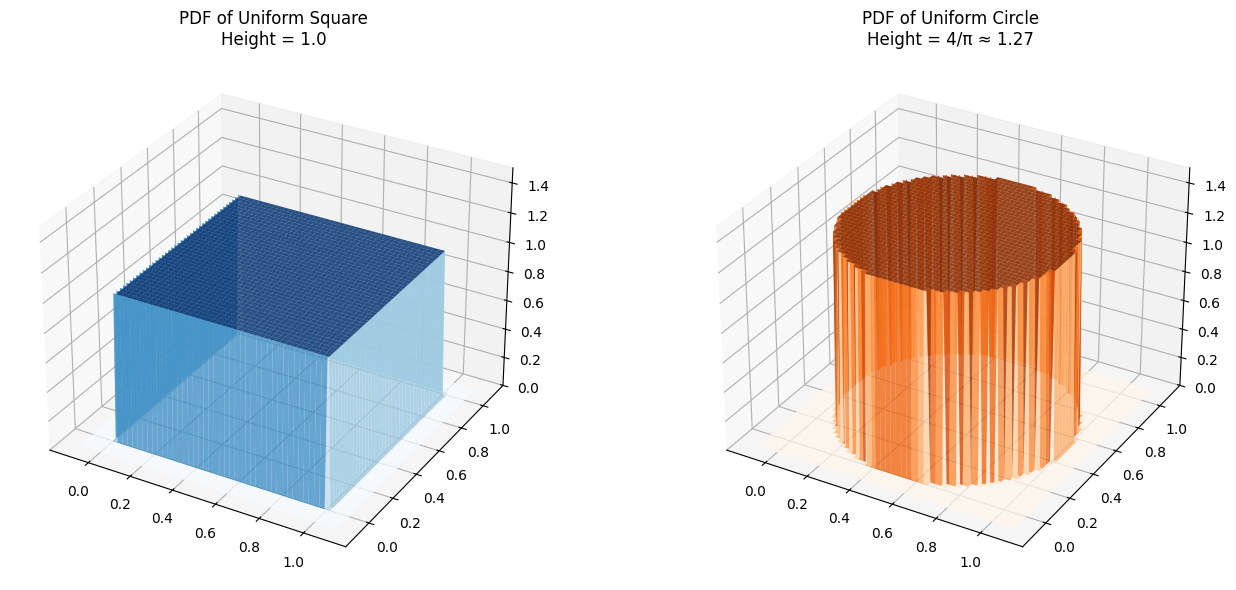

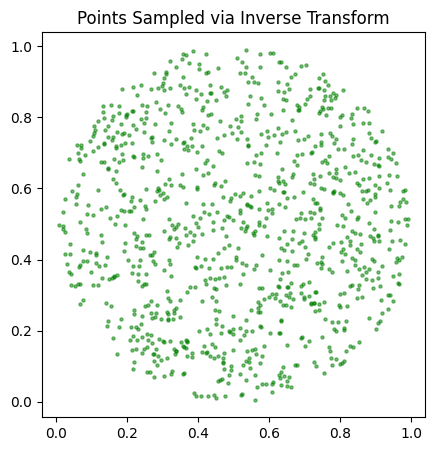

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup Grid
x = np.linspace(-0.1, 1.1, 100)
y = np.linspace(-0.1, 1.1, 100)
X, Y = np.meshgrid(x, y)

# 2. Define PDFs
# Square PDF (Height = 1 inside [0,1]x[0,1])
pdf_square = np.where((X >= 0) & (X <= 1) & (Y >= 0) & (Y <= 1), 1.0, 0.0)

# Circle PDF (Height = 4/pi inside circle centered at 0.5,0.5 with r=0.5)
radius_sq = (X - 0.5)**2 + (Y - 0.5)**2
pdf_circle = np.where(radius_sq <= 0.5**2, 4/np.pi, 0.0)

# 3. Plotting
fig = plt.figure(figsize=(14, 6))

# Plot Square PDF
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, pdf_square, cmap='Blues', alpha=0.8)
ax1.set_title("PDF of Uniform Square\nHeight = 1.0")
ax1.set_zlim(0, 1.5)

# Plot Circle PDF
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, pdf_circle, cmap='Oranges', alpha=0.8)
ax2.set_title("PDF of Uniform Circle\nHeight = 4/π ≈ 1.27")
ax2.set_zlim(0, 1.5)

plt.tight_layout()
plt.show()

# 4. Inverse Transform Sampling implementation
def sample_circle_inverse(n_samples):
    u1 = np.random.uniform(0, 1, n_samples)
    u2 = np.random.uniform(0, 1, n_samples)

    r = 0.5 * np.sqrt(u1)  # Inverse CDF for radius
    theta = 2 * np.pi * u2 # Inverse CDF for angle

    # Map back to Cartesian (centered at 0.5, 0.5)
    x = 0.5 + r * np.cos(theta)
    y = 0.5 + r * np.sin(theta)
    return x, y

# Quick check plot
xs, ys = sample_circle_inverse(1000)
plt.figure(figsize=(5,5))
plt.scatter(xs, ys, s=5, alpha=0.5, color='green')
plt.title("Points Sampled via Inverse Transform")
plt.gca().set_aspect('equal')
plt.show()

KeyboardInterrupt: 

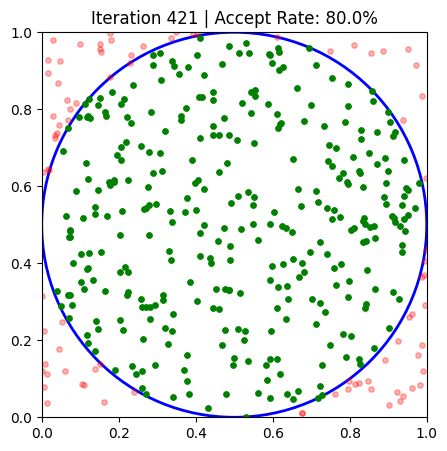

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Parameters
N_TOTAL = 2000 # Lower this if it's too slow, increase for more points
CENTER = (0.5, 0.5)
RADIUS = 0.5

pts_acc = []
pts_rej = []

# Create the static figure once
fig, ax = plt.subplots(figsize=(5, 5))

for i in range(N_TOTAL):
    # 1. Sample new point
    pt = np.random.uniform(0, 1, 2)
    dist_sq = (pt[0]-0.5)**2 + (pt[1]-0.5)**2

    if dist_sq <= RADIUS**2:
        pts_acc.append(pt)
    else:
        pts_rej.append(pt)

    # 2. Only update the plot every few frames to keep it fast
    if i % 5 == 0 or i == N_TOTAL - 1:
        ax.cla() # Clear axis
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')

        # Draw target boundary
        circle = plt.Circle(CENTER, RADIUS, color='blue', fill=False, lw=2)
        ax.add_artist(circle)

        # Plot points
        if pts_acc:
            acc_arr = np.array(pts_acc)
            ax.scatter(acc_arr[:,0], acc_arr[:,1], c='green', s=15, label='Accepted')
        if pts_rej:
            rej_arr = np.array(pts_rej)
            ax.scatter(rej_arr[:,0], rej_arr[:,1], c='red', s=15, alpha=0.3, label='Rejected')

        # Stats
        acc_rate = (len(pts_acc) / (i+1)) * 100
        ax.set_title(f"Iteration {i+1} | Accept Rate: {acc_rate:.1f}%")

        # 3. Magic to make it "live"
        clear_output(wait=True)
        display(fig)

plt.close() # Prevents a double-plot at the end

# Acceptnce Rate $ \approx \frac{\mathrm{Circle's \quad Area}}{\mathrm{Square's \quad Area}} = \frac{\pi r^2}{(2r)^2} = \frac{\pi}{4} = 78\%$

KeyboardInterrupt: 

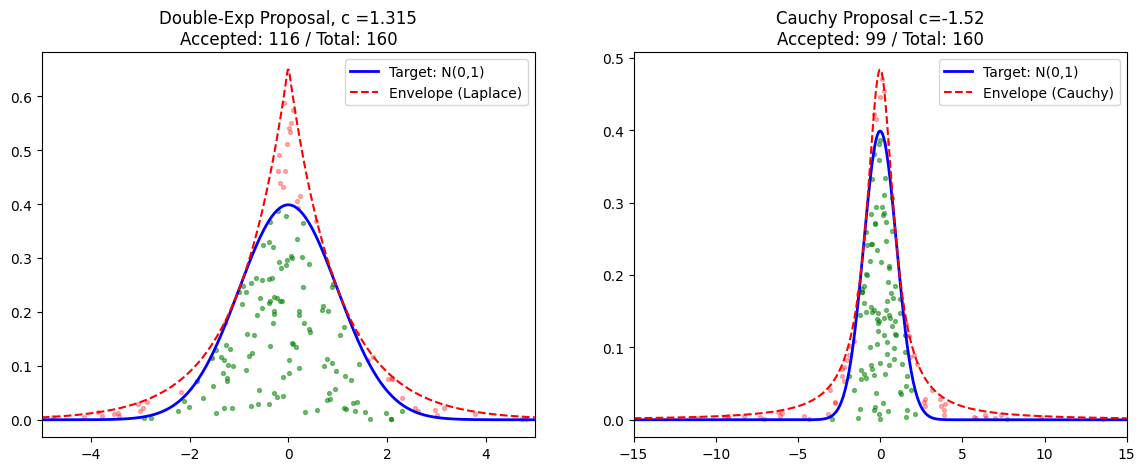

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.stats import norm, cauchy, expon

# Theoretical Constants
M_EXP = np.sqrt(2 * np.e / np.pi)     # ~1.315
M_CAUCHY = np.sqrt(2 * np.pi / np.e)  # ~1.520
N_ITER = 2000

# Data containers
exp_data = {'acc': [], 'rej': []}
cau_data = {'acc': [], 'rej': []}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i in range(1, N_ITER + 1):
    # --- 1. EXPONENTIAL (LAPLACE) PROPOSAL ---
    # Sample from Exp(1) and randomly assign sign
    x_e_base = np.random.exponential(1)
    sign = 1 if np.random.rand() > 0.5 else -1
    x_e = x_e_base * sign

    # The envelope is M * 0.5 * exp(-|x|)
    envelope_e = M_EXP * 0.5 * np.exp(-np.abs(x_e))
    u_e = np.random.uniform(0, envelope_e)
    f_e = norm.pdf(x_e)

    if u_e <= f_e:
        exp_data['acc'].append([x_e, u_e])
    else:
        exp_data['rej'].append([x_e, u_e])

    # --- 2. CAUCHY PROPOSAL ---
    x_c = np.random.standard_cauchy()
    u_c = np.random.uniform(0, M_CAUCHY * cauchy.pdf(x_c))
    f_c = norm.pdf(x_c)

    if u_c <= f_c:
        cau_data['acc'].append([x_c, u_c])
    else:
        if -15 <= x_c <= 15:
            cau_data['rej'].append([x_c, u_c])

    # --- UPDATING PLOTS ---
    if i % 20 == 0 or i == N_ITER:
        clear_output(wait=True)

        # Plot 1: Full Exponential (Laplace)
        ax1.cla()
        xe_range = np.linspace(-5, 5, 400)
        ax1.plot(xe_range, norm.pdf(xe_range), 'b', lw=2, label='Target: N(0,1)')
        # Laplace density: 0.5 * exp(-|x|)
        ax1.plot(xe_range, M_EXP * 0.5 * np.exp(-np.abs(xe_range)), 'r--', label='Envelope (Laplace)')

        if exp_data['acc']:
            pts = np.array(exp_data['acc'])
            ax1.scatter(pts[:,0], pts[:,1], c='green', s=8, alpha=0.5)
        if exp_data['rej']:
            pts = np.array(exp_data['rej'])
            ax1.scatter(pts[:,0], pts[:,1], c='red', s=8, alpha=0.3)
        ax1.set_xlim(-5, 5)
        ax1.set_title(f"Double-Exp Proposal, c =1.315\nAccepted: {len(exp_data['acc'])} / Total: {i}")
        ax1.legend(loc='upper right')

        # Plot 2: Cauchy
        ax2.cla()
        xc_range = np.linspace(-15, 15, 500)
        ax2.plot(xc_range, norm.pdf(xc_range), 'b', lw=2, label='Target: N(0,1)')
        ax2.plot(xc_range, M_CAUCHY * cauchy.pdf(xc_range), 'r--', label='Envelope (Cauchy)')

        if cau_data['acc']:
            pts = np.array(cau_data['acc'])
            ax2.scatter(pts[:,0], pts[:,1], c='green', s=8, alpha=0.5)
        if cau_data['rej']:
            pts = np.array(cau_data['rej'])
            ax2.scatter(pts[:,0], pts[:,1], c='red', s=8, alpha=0.3)
        ax2.set_xlim(-15, 15)
        ax2.set_title(f"Cauchy Proposal c=-1.52\nAccepted: {len(cau_data['acc'])} / Total: {i}")
        ax2.legend(loc='upper right')

        display(fig)

plt.close()